[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/pace-avw.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-PACE/pace-avw.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/pace-avw.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2025/main/topics-2025/2025-PACE/pace-avw.ipynb

>📘 Learning Objectives
>
> 1. Show how to work with the `earthaccess` package for PACE data
> 2. Create a NASA EDL session for authentication
> 3. Load single files with `xarray.open_dataset`
> 4. Load multiple files with `xarray.open_mfdataset`

## Overview

The PACE Level-3 (gridded) OCI (ocean color instrument) data is available on an NASA EarthData. Search using the instrument filter "OCI" and processing level filter "Gridded Observations" <https://search.earthdata.nasa.gov/search?fi=OCI&fl=3%2B-%2BGridded%2BObservations> and you will see 45+ data collections. In this tutorial, we will look at the Apparent Visible Wavelength (AVW) product.

### Prerequisites

You need to have an EarthData Login username and password. Go here to get one <https://urs.earthdata.nasa.gov/>

I assume you have a `.netrc` file at `~` (home). `~/.netrc` should look just like this with your username and password. Create that file if needed. You don't need to create it if you don't have this file. The `earthaccess.login(persist=True)` line will ask for your username and password and create the `.netrc` file for you.

```
machine urs.earthdata.nasa.gov
        login yourusername
        password yourpassword
```

#### For those not working in the JupyterHub

Create a code cell and run `pip install earthaccess`.


## Apparent Visible Wavelength (AVW)

[PACE OCI Level-3 Global Mapped Apparent Visible Wavelength (AVW) Data, version 3.0](https://cmr.earthdata.nasa.gov/search/concepts/C3385050418-OB_CLOUD.html). The concept id for this dataset is "C3385050418-OB_CLOUD" and the short name is "PACE_OCI_L3M_AVW".

### Create a NASA EDL authenticated session

Authenticate with `earthaccess.login()`.

In [1]:
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

### Import Required Packages

In [2]:
import xarray as xr

## Apparent Visible Wavelength (AVW)

Load the data.

### Find the monthly data

I poked around on the files on [search.earthdata](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C3385050418-OB_CLOUD&pg[0][v]=f&pg[0][gsk]=-start_date&fi=OCI&fl=3%2B-%2BGridded%2BObservations&tl=1726833236.2!4!!&lat=0.0703125) so I know what the files look like.

In [12]:
import earthaccess
results_mo = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_AVW",
    temporal = ("2024-03-01", "2024-10-31"),
    granule_name="*.MO.*.0p1deg.*"
)
len(results_mo)

8

In [4]:
results_mo[0]

Collection: {'Version': '3.0', 'ShortName': 'PACE_OCI_L3M_AVW'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180, 'NorthBoundingCoordinate': 90, 'EastBoundingCoordinate': 180, 'SouthBoundingCoordinate': -90}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-03-05T00:00:00Z', 'EndingDateTime': '2024-03-31T23:59:59Z'}}
Size(MB): 7.85748291015625
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240301_20240331.L3m.MO.AVW.V3_0.avw.0p1deg.nc']

In [13]:
# Create a fileset
fileset = earthaccess.open(results_mo);

QUEUEING TASKS | :   0%|          | 0/8 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/8 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/8 [00:00<?, ?it/s]

In [15]:
# let's load just one month
import xarray as xr
ds = xr.open_dataset(fileset[0])
ds

<xarray.Dataset> Size: 26MB
Dimensions:  (lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    avw      (lat, lon) float32 26MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/62)
    product_name:                      PACE_OCI.20240301_20240331.L3m.MO.AVW....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/AVW/3.0
    data_bins:                         3016790
    data_minimum:                      399.99997
    data_maximum:                      700.00006

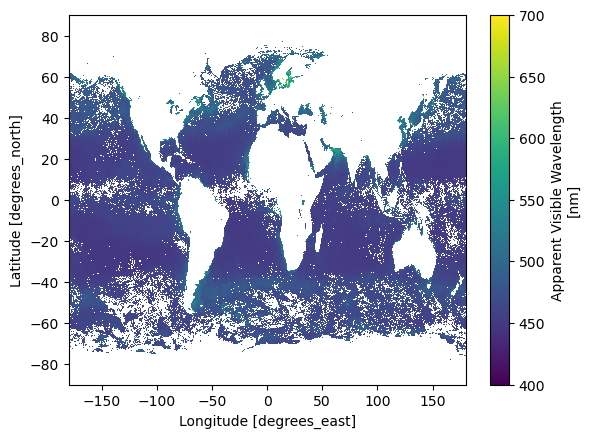

In [16]:
ds["avw"].plot();

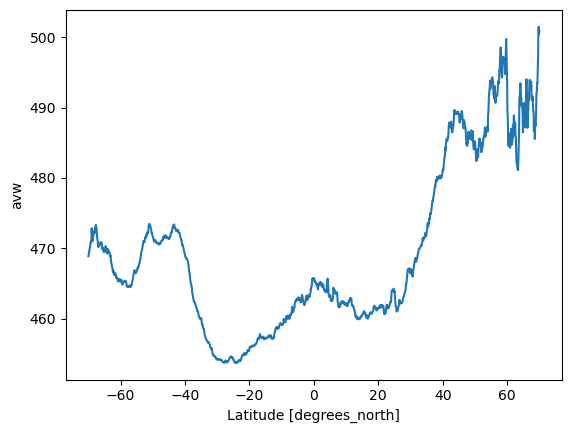

In [17]:
lat_mean = ds["avw"].sel(lat = slice(70, -70)).mean(dim=["lon"])
lat_mean.plot.line(x="lat");

### Multiple months

In [61]:
ds = xr.open_mfdataset(
    fileset,
    combine='nested', concat_dim="time"
)
ds

<xarray.Dataset> Size: 207MB
Dimensions:  (time: 8, lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: time, rgb, eightbitcolor
Data variables:
    avw      (time, lat, lon) float32 207MB dask.array<chunksize=(1, 512, 1024), meta=np.ndarray>
    palette  (time, rgb, eightbitcolor) uint8 6kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/62)
    product_name:                      PACE_OCI.20240301_20240331.L3m.MO.AVW....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/AVW/3.0
    data_bins:                         3016790
    data_minimum:                      399.99997
    data_maximum:                      700.00006

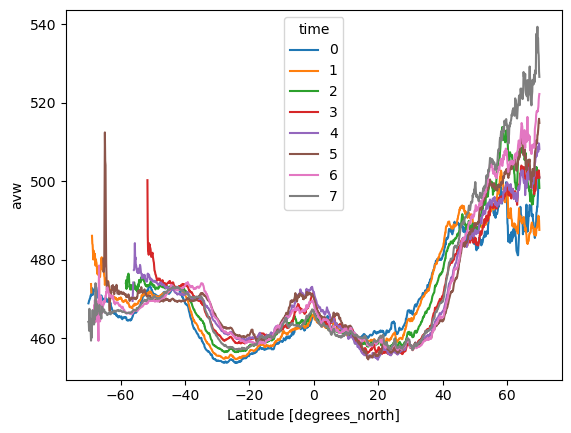

In [62]:
lat_mean = ds["avw"].sel(lat = slice(70, -70)).mean(dim=["lon"])
lat_mean.plot.line(x="lat");

### Find the daily data

We need the data links that are 0.1 deg and DAY.

In [18]:
import earthaccess
results_day = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_AVW",
    temporal = ("2024-03-01", "2024-03-31"),
    granule_name="*.DAY.*.0p1deg.*"
)
len(results_day)

23

In [9]:
results_day[0]

Collection: {'ShortName': 'PACE_OCI_L3M_AVW', 'Version': '3.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'NorthBoundingCoordinate': 90, 'SouthBoundingCoordinate': -90, 'WestBoundingCoordinate': -180, 'EastBoundingCoordinate': 180}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-03-05T00:00:00Z', 'EndingDateTime': '2024-03-05T23:59:59Z'}}
Size(MB): 2.2527074813842773
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240305.L3m.DAY.AVW.V3_0.avw.0p1deg.nc']

In [10]:
# let's load the data
fileset = earthaccess.open(results_day)

QUEUEING TASKS | :   0%|          | 0/23 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/23 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/23 [00:00<?, ?it/s]

In [8]:
ds = xr.open_mfdataset(
    fileset,
    combine='nested', concat_dim="time"
)
ds

<xarray.Dataset> Size: 363MB
Dimensions:  (time: 14, lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: time, rgb, eightbitcolor
Data variables:
    avw      (time, lat, lon) float32 363MB dask.array<chunksize=(1, 512, 1024), meta=np.ndarray>
    palette  (time, rgb, eightbitcolor) uint8 11kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/62)
    product_name:                      PACE_OCI.20240305.L3m.DAY.AVW.V3_0.avw...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/AVW/3.0
    data_bins:                         571271
    data_minimum:                      399.99997
    data_maximum:                      700.0001

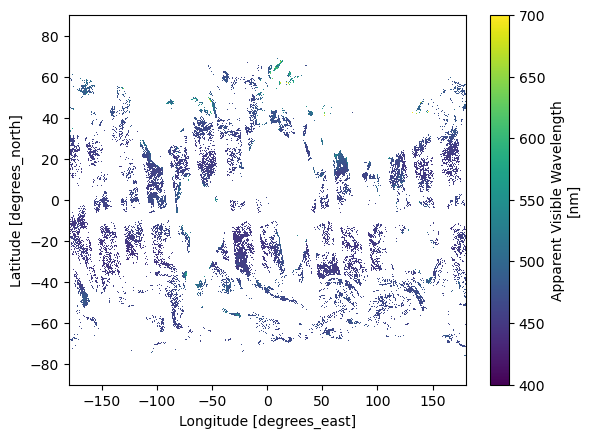

In [71]:
ds["avw"].isel(time=0).plot();

In [72]:
import matplotlib.pyplot as plt
import gc
plt.show()
plt.clf()       # Clear the current figure
plt.close()     # Close the figure window
gc.collect()    # Ask Python to free up memory


32562

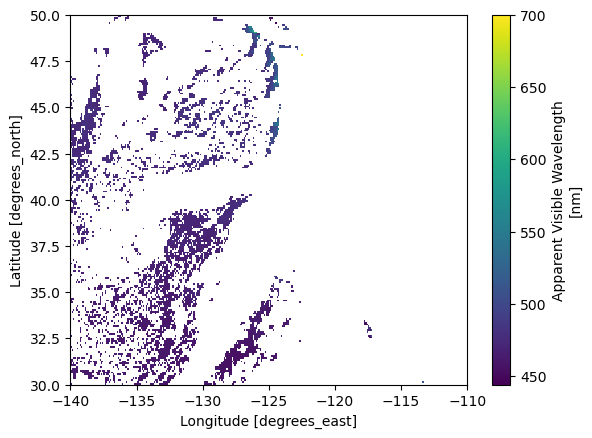

In [73]:
# let's look at the west coast of USA
ds["avw"].isel(time=0).sel(lat = slice(50, 30), lon=slice(-140, -110)).plot();

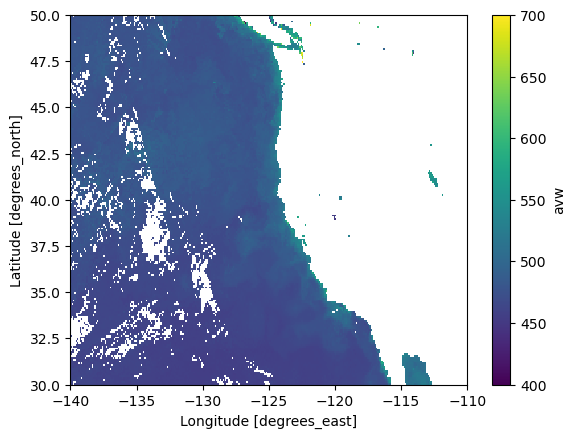

In [77]:
ds_mean = ds["avw"].mean(dim="time");
ds_mean.sel(lat = slice(50, 30), lon=slice(-140, -110)).plot();

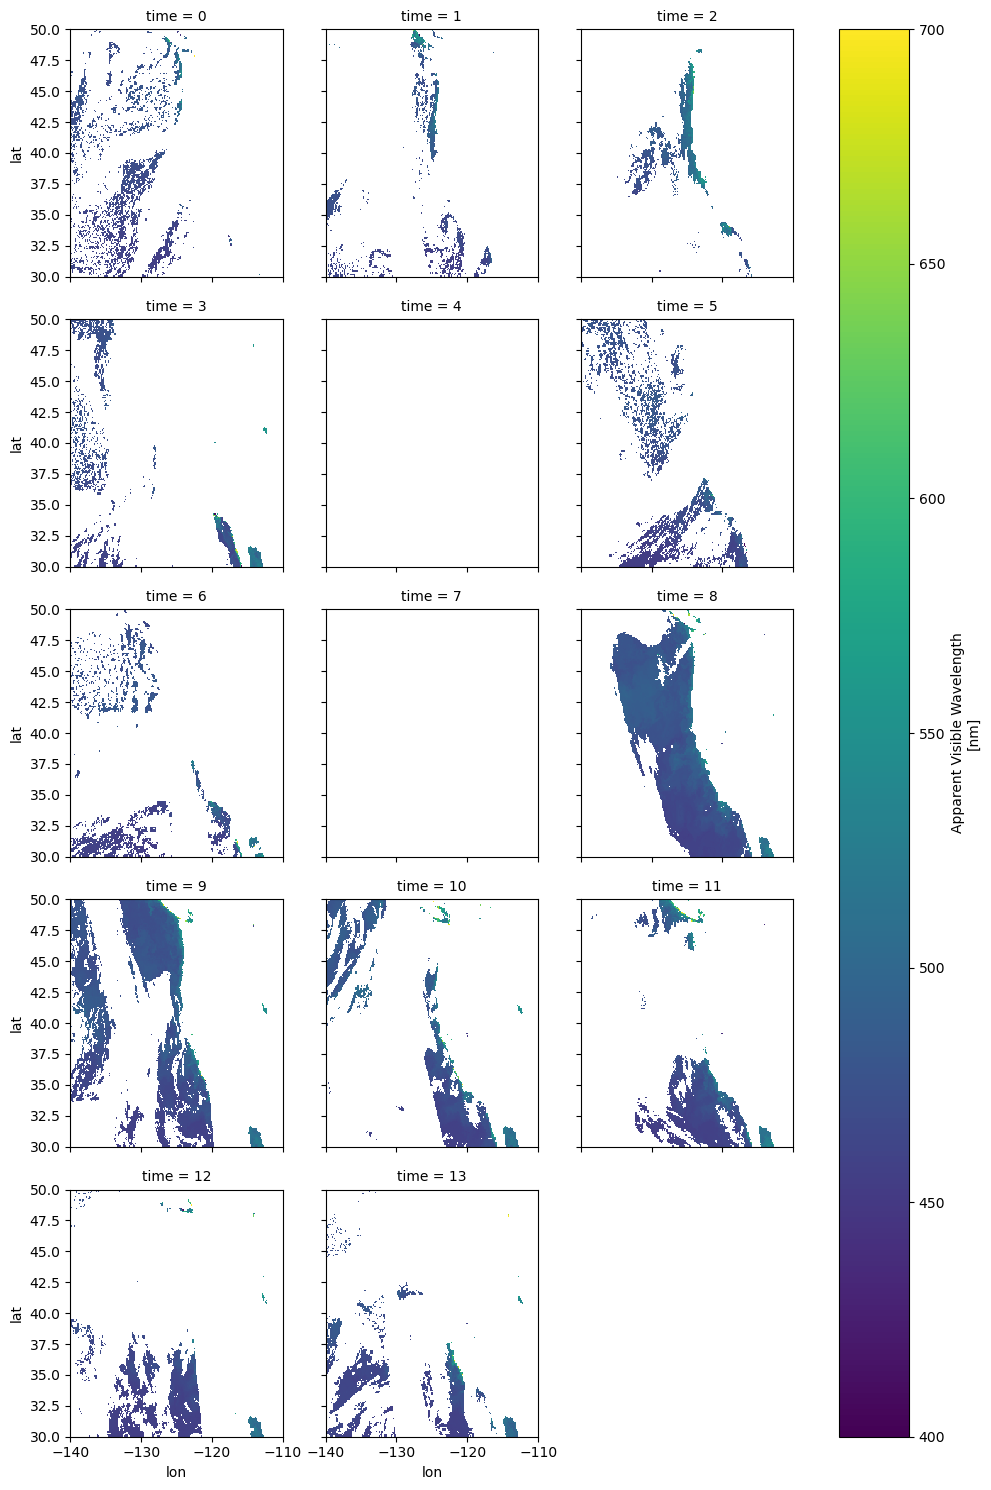

In [10]:
# We can plot over the days to see when it was cloudy
ds['avw'].sel(lat = slice(50, 30), lon=slice(-140, -110)).plot(x='lon', y='lat', col="time", col_wrap=3);

## References

* [An Introduction to Earth and Environmental Data Science](https://earth-env-data-science.github.io)
* [xarray user guide](https://docs.xarray.dev/en/stable/user-guide/index.html)